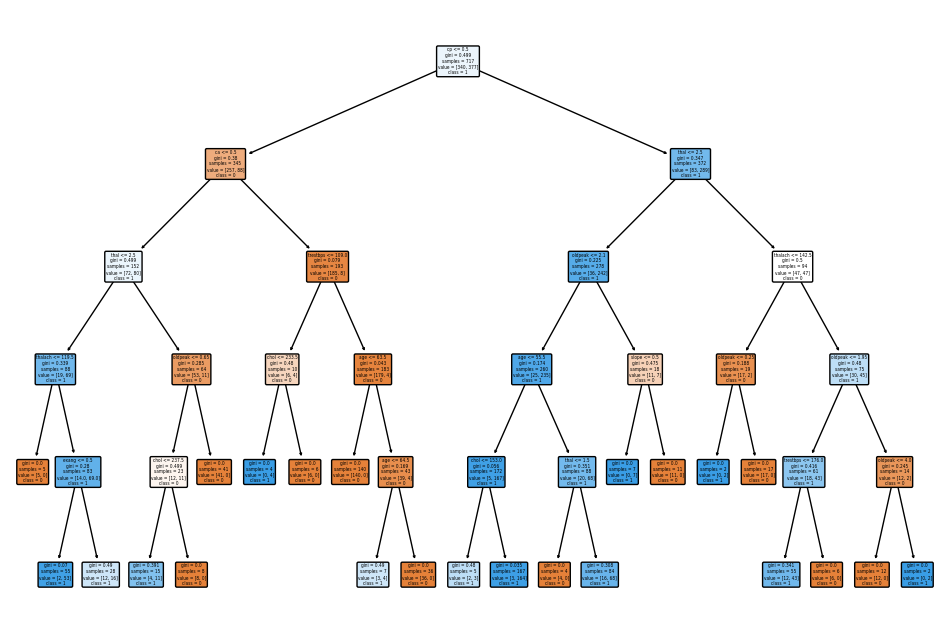

Decision Tree CV Accuracy: 0.8907317073170733
Random Forest CV Accuracy: 0.9970731707317073
          Importance
cp          0.132274
thalach     0.125039
ca          0.122912
oldpeak     0.122852
thal        0.113005
age         0.085554
chol        0.079872
trestbps    0.068356
slope       0.051335
exang       0.042210
sex         0.028721
restecg     0.018155
fbs         0.009714


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("heart.csv")

# Prepare the data
X = data.drop(columns=["target"])
y = data["target"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Decision Tree Classifier
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Visualize the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=["0", "1"], rounded=True)
plt.show()

# Evaluate Decision Tree using cross-validation
dt_cv_scores = cross_val_score(dt, X, y, cv=5)
print(f"Decision Tree CV Accuracy: {dt_cv_scores.mean()}")

# Train a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate Random Forest using cross-validation
rf_cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"Random Forest CV Accuracy: {rf_cv_scores.mean()}")

# Interpret feature importances
feature_importances = pd.DataFrame(rf.feature_importances_, index=X.columns, columns=["Importance"]).sort_values("Importance", ascending=False)
print(feature_importances)
